# Détection de fraude bancaire par Machine Learning

---

| | |
|---|---|
| **Module** | Machine Learning — Master 2 CDSD |
| **Auteur** | Steeve NGUEMA |

---

## Résumé exécutif

Presentation de la démarche complète de développement d'un système de détection automatique des transactions frauduleuses au sein d'une institution financière.

Face à un jeu de données fortement déséquilibré (~0,1 % de fraudes), nous appliquons une pipeline rigoureuse allant de l'analyse exploratoire jusqu'à l'interprétabilité des modèles, en passant par le prétraitement, la modélisation comparative et le suivi d'expériences MLflow.

**Objectif métier** : minimiser les fraudes non détectées (faux négatifs) tout en limitant les fausses alertes (faux positifs) qui dégradent l'expérience client.

---

## Table des matières

1. [Initialisation et description des données](#1)
2. [Analyse exploratoire des données (EDA)](#2)
3. [Prétraitement](#3)
4. [Modélisation](#4)
5. [Évaluation et comparaison des modèles](#5)
6. [Interprétabilité](#6)
7. [Conclusion et recommandations](#7)

---

## Configuration de l'environnement

Chargement des librairies et des modules internes du projet.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import tensorflow as tf
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.tensorflow
import shap

from src.evaluation import evaluer_modele
from src.models import (
    entrainer_regression_logistique,
    entrainer_random_forest,
    entrainer_xgboost,
    entrainer_lightgbm,
    construire_reseau_neurones
)
from src.utils import sauvegarder_modele

sns.set_theme(style='whitegrid')

---

## 1. Initialisation et description des données

### 1.1 Source des données

Le jeu de données est issu d'une simulation de transactions financières mobiles. Il contient les variables suivantes :

| Variable | Type | Description |
|---|---|---|
| `step` | Entier | Unité temporelle de la transaction |
| `type` | Catégoriel | Type de transaction (PAYMENT, TRANSFER, CASH_OUT, DEBIT, CASH_IN) |
| `amount` | Continu | Montant transféré |
| `nameOrig` | Identifiant | Client émetteur |
| `oldbalanceOrg` | Continu | Solde émetteur avant transaction |
| `newbalanceOrig` | Continu | Solde émetteur après transaction |
| `nameDest` | Identifiant | Client destinataire |
| `oldbalanceDest` | Continu | Solde destinataire avant transaction |
| `newbalanceDest` | Continu | Solde destinataire après transaction |
| `isFraud` | Binaire | **Variable cible** — 1 = fraude, 0 = normale |
| `isFlaggedFraud` | Binaire | Signal du système existant (exclu de la modélisation) |

### 1.2 Initialisation

In [3]:
df = pd.read_csv('../donnees/brutes/détection_de_fraude.csv', sep=';')
print(f'Dimensions : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
df.head()

Dimensions : 1,048,575 lignes x 11 colonnes


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
print('Types des variables :')
print(df.dtypes)
print(f'\nValeurs manquantes :\n{df.isnull().sum()}')

Types des variables :
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Valeurs manquantes :
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,2.696617e+01,1.586670e+05,8.740055e+05,8.938049e+05,9.781600e+05,1.114193e+06,1.089097e-03,0.0
std,1.562325e+01,2.649409e+05,2.971725e+06,3.008246e+06,2.296779e+06,2.416554e+06,3.298351e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.893942e+07,3.894623e+07,4.205466e+07,4.216916e+07,1.000000e+00,0.0


**Observations** : Le jeu de données ne présente aucune valeur manquante. Les montants (`amount`) varient fortement, justifiant une normalisation.

---

## 2. Analyse Exploratoire des Données (EDA)

L'analyse exploratoire vise à comprendre la structure du jeu de données, identifier les patterns caractéristiques des transactions frauduleuses, et orienter les choix de prétraitement.

### 2.1 Distribution de la variable cible

La variable cible `isFraud` est binaire. Son taux de fraude est attendu très faible, ce qui constitue le principal défi.

Taux de fraude : 0.1089%
isFraud
0    1047433
1       1142
Name: count, dtype: int64


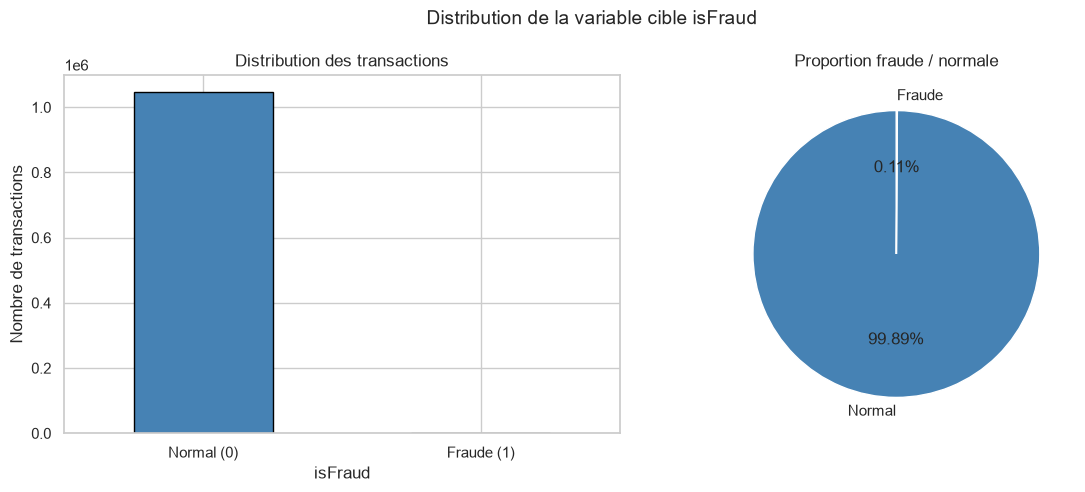

In [6]:
taux_fraude = df['isFraud'].mean() * 100
print(f'Taux de fraude : {taux_fraude:.4f}%')
print(df['isFraud'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['isFraud'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'crimson'], edgecolor='black'
)
axes[0].set_title('Distribution des transactions')
axes[0].set_xticklabels(['Normal (0)', 'Fraude (1)'], rotation=0)
axes[0].set_ylabel('Nombre de transactions')

axes[1].pie(
    df['isFraud'].value_counts(),
    labels=['Normal', 'Fraude'],
    autopct='%1.2f%%',
    colors=['steelblue', 'crimson'],
    startangle=90
)
axes[1].set_title('Proportion fraude / normale')

plt.suptitle('Distribution de la variable cible isFraud', fontsize=14)
plt.tight_layout()
plt.show()

**Observation** : Le déséquilibre est extrême — les fraudes représentent moins de 0,2 % des transactions. L'accuracy ne peut pas être la métrique principale. Le **Recall** (taux de fraudes détectées) et le **F1-Score** sur la classe fraude seront les indicateurs de référence tout au long de l'analyse.

### 2.2 Répartition des fraudes par type de transaction

Certains types de transactions sont structurellement plus exposés à la fraude. Cette analyse permet d'identifier les canaux à risque.

    type  nb_fraudes  nb_total  taux_fraude  taux_fraude_pct
TRANSFER         564     86753     0.006501         0.650122
CASH_OUT         578    373641     0.001547         0.154694
 CASH_IN           0    227130     0.000000         0.000000
   DEBIT           0      7178     0.000000         0.000000
 PAYMENT           0    353873     0.000000         0.000000


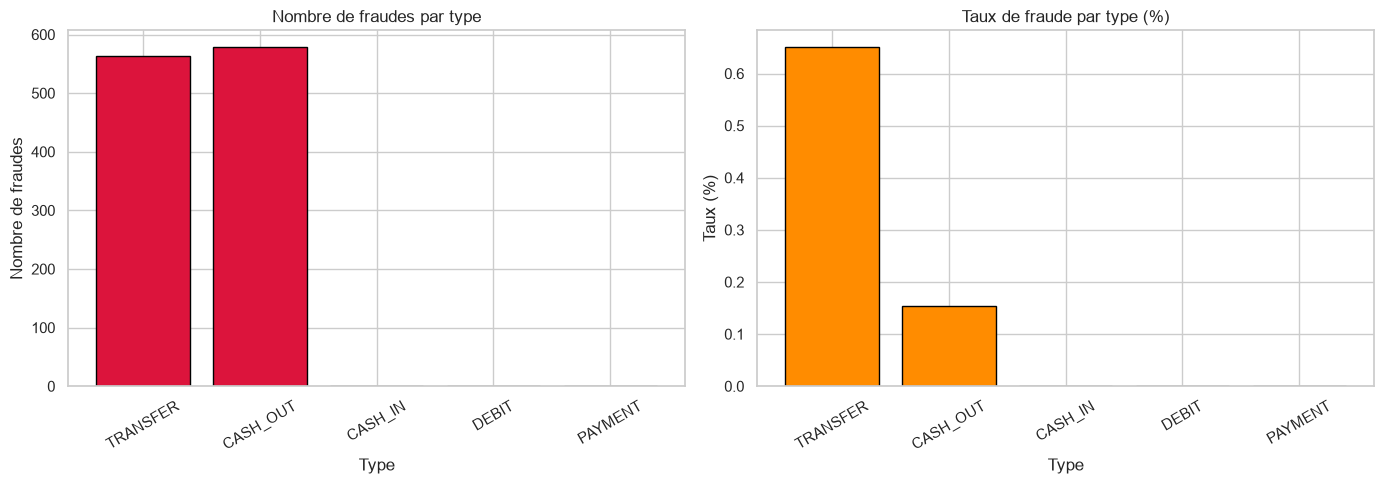

In [7]:
fraude_par_type = df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean']).reset_index()
fraude_par_type.columns = ['type', 'nb_fraudes', 'nb_total', 'taux_fraude']
fraude_par_type['taux_fraude_pct'] = fraude_par_type['taux_fraude'] * 100
fraude_par_type = fraude_par_type.sort_values('taux_fraude_pct', ascending=False)
print(fraude_par_type.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(fraude_par_type['type'], fraude_par_type['nb_fraudes'], color='crimson', edgecolor='black')
axes[0].set_title('Nombre de fraudes par type')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Nombre de fraudes')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(fraude_par_type['type'], fraude_par_type['taux_fraude_pct'], color='darkorange', edgecolor='black')
axes[1].set_title('Taux de fraude par type (%)')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Taux (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Observation** : Les fraudes se concentrent exclusivement sur deux types de transactions : **CASH_OUT** (retrait) et **TRANSFER** (virement). Les types PAYMENT, DEBIT et CASH_IN ne présentent aucune fraude. Cette observation oriente directement la stratégie de surveillance opérationnelle.

### 2.3 Distribution des montants transactionnels

L'analyse des montants vise à déterminer si les transactions frauduleuses se distinguent des transactions normales par leur valeur financière.

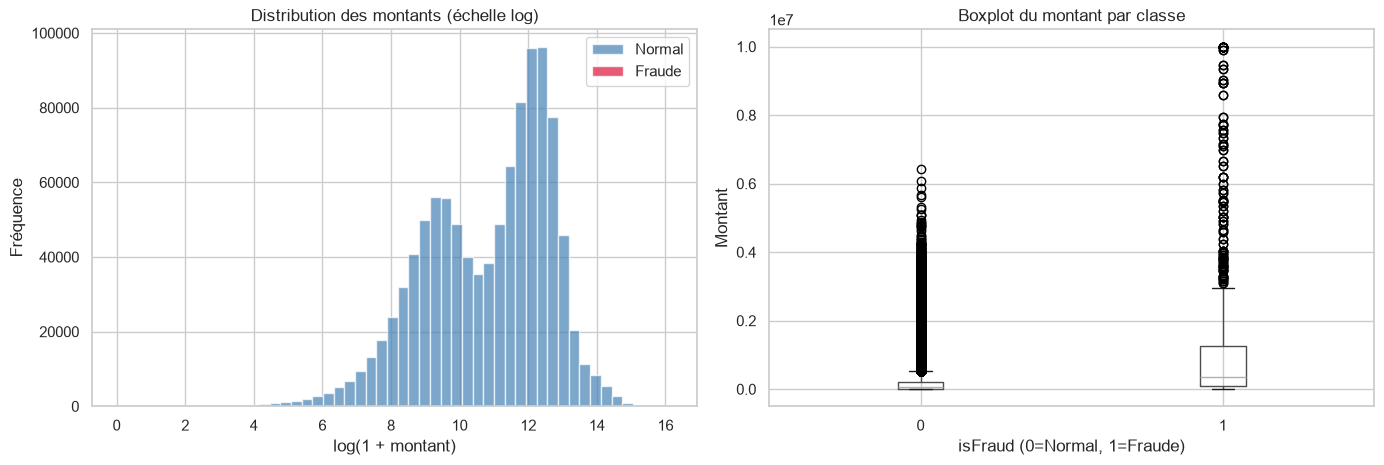

Statistiques du montant par classe :
             count          mean           std    min       25%        50%  \
isFraud                                                                      
0        1047433.0  1.575397e+05  2.541883e+05    0.1  12134.87   76214.97   
1           1142.0  1.192629e+06  2.030599e+06  119.0  86070.17  353179.45   

                  75%          max  
isFraud                             
0        2.134928e+05   6419835.27  
1        1.248759e+06  10000000.00  


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(df[df['isFraud'] == 0]['amount']), bins=50, alpha=0.7, color='steelblue', label='Normal')
axes[0].hist(np.log1p(df[df['isFraud'] == 1]['amount']), bins=50, alpha=0.7, color='crimson', label='Fraude')
axes[0].set_title('Distribution des montants (échelle log)')
axes[0].set_xlabel('log(1 + montant)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

df.boxplot(column='amount', by='isFraud', ax=axes[1])
axes[1].set_title('Boxplot du montant par classe')
axes[1].set_xlabel('isFraud (0=Normal, 1=Fraude)')
axes[1].set_ylabel('Montant')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Statistiques du montant par classe :')
print(df.groupby('isFraud')['amount'].describe())

**Observation** : Les transactions frauduleuses tendent à porter sur des montants plus élevés, avec une distribution plus concentrée. La variable `amount` présente un fort pouvoir discriminant.

### 2.4 Détection des comportements suspects

Les fraudes laissent souvent des traces dans les soldes des comptes. On recherche deux patterns typiques : le solde émetteur vidé à zéro et le solde destinataire inchangé après réception.

In [9]:
solde_zero = df[(df['newbalanceOrig'] == 0) & (df['isFraud'] == 1)]
print(f'Fraudes avec solde émetteur à 0 : {len(solde_zero):,} ({len(solde_zero)/df["isFraud"].sum()*100:.1f}% des fraudes)')

dest_inchange = df[(df['oldbalanceDest'] == df['newbalanceDest']) & (df['isFraud'] == 1)]
print(f'Fraudes avec solde destinataire inchangé : {len(dest_inchange):,} ({len(dest_inchange)/df["isFraud"].sum()*100:.1f}% des fraudes)')

print('\nStatistiques des soldes pour les transactions frauduleuses :')
print(df[df['isFraud'] == 1][['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].describe())

Fraudes avec solde émetteur à 0 : 1,133 (99.2% des fraudes)
Fraudes avec solde destinataire inchangé : 543 (47.5% des fraudes)

Statistiques des soldes pour les transactions frauduleuses :
       oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest
count   1.142000e+03    1.142000e+03    1.142000e+03    1.142000e+03
mean    1.218656e+06    3.394432e+04    4.528040e+05    1.077944e+06
std     2.229986e+06    5.012930e+05    1.661384e+06    2.434547e+06
min     0.000000e+00    0.000000e+00    0.000000e+00    0.000000e+00
25%     7.802889e+04    0.000000e+00    0.000000e+00    0.000000e+00
50%     3.487051e+05    0.000000e+00    0.000000e+00    1.379876e+04
75%     1.218166e+06    0.000000e+00    1.617654e+05    9.685277e+05
max     1.988782e+07    9.887819e+06    3.296166e+07    3.464570e+07


**Observation** : Ces deux anomalies de soldes sont présentes dans une très grande proportion des fraudes. Ces patterns deviennent des **variables synthétiques** à fort pouvoir prédictif, créées lors du feature engineering (section 3.2).

### 2.5 Matrice de corrélation

La matrice de corrélation permet d'identifier les relations linéaires entre variables numériques et la variable cible, et de détecter d'éventuelles colinéarités.

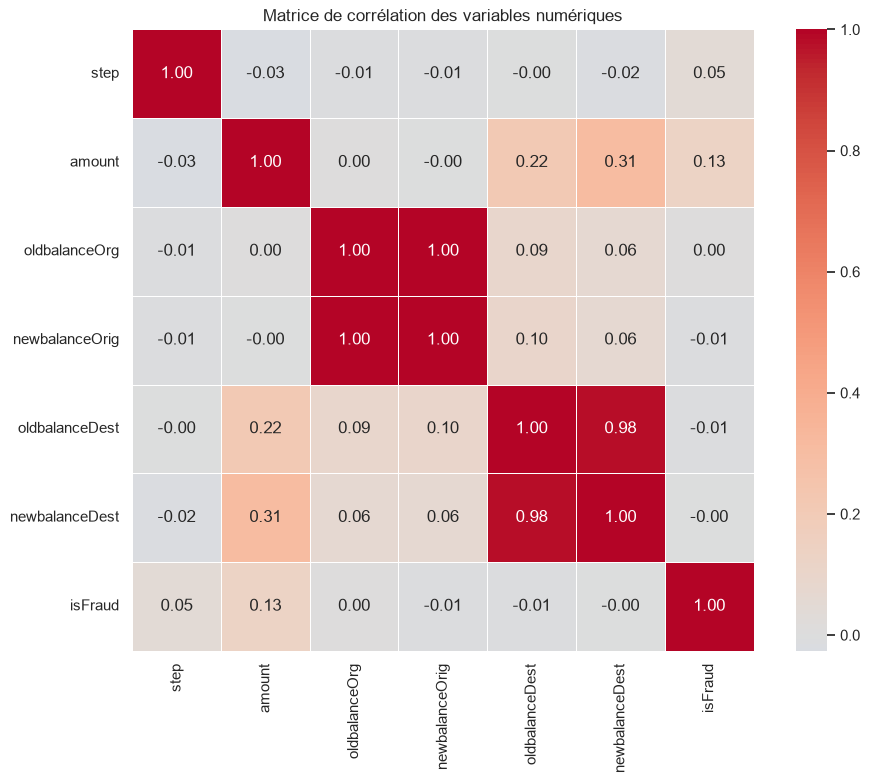

In [10]:
cols_num = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
corr = df[cols_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques')
plt.tight_layout()
plt.show()

**Observation** : Les variables de soldes (`oldbalanceOrg`, `newbalanceOrig`) sont fortement corrélées entre elles, ce qui est attendu. La corrélation directe avec `isFraud` est faible pour toutes les variables brutes — ce qui confirme que la modélisation nécessite des variables dérivées pour capturer les patterns frauduleux.

---

**Synthèse EDA** : Les transactions frauduleuses se caractérisent par : 
- un type exclusivement CASH_OUT ou TRANSFER
- des montants élevés
- des anomalies dans les soldes avant/après transaction. Ces éléments guident directement les choix de prétraitement.

---

## 3. Prétraitement

Le prétraitement suit un ordre strict pour éviter toute fuite d'information (*data leakage*) :

> Suppression → Feature Engineering → Encodage → Split → Normalisation → SMOTE

### 3.1 Suppression des colonnes non pertinentes

- `nameOrig` et `nameDest` : identifiants uniques sans pouvoir prédictif généralisable.
- `isFlaggedFraud` : variable de signal du système existant — l'inclure fausserait l'évaluation.

In [11]:
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])
print(f'Dimensions après suppression : {df.shape}')

Dimensions après suppression : (1048575, 8)


### 3.2 Feature Engineering

Quatre variables synthétiques sont créées à partir des anomalies de soldes observées en EDA :

| Nouvelle variable | Formule | Signification |
|---|---|---|
| `diff_solde_orig` | `oldbalanceOrg - newbalanceOrig` | Montant débité du compte émetteur |
| `diff_solde_dest` | `newbalanceDest - oldbalanceDest` | Montant crédité au destinataire |
| `erreur_solde_orig` | `diff_solde_orig - amount` | Écart entre débit réel et montant déclaré |
| `erreur_solde_dest` | `diff_solde_dest - amount` | Écart entre crédit réel et montant déclaré |

Un écart non nul sur `erreur_solde_orig` ou `erreur_solde_dest` signale une incohérence comptable caractéristique des fraudes.

In [12]:
df['diff_solde_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['diff_solde_dest'] = df['newbalanceDest'] - df['oldbalanceDest']
df['erreur_solde_orig'] = df['diff_solde_orig'] - df['amount']
df['erreur_solde_dest'] = df['diff_solde_dest'] - df['amount']

print(f'Dimensions après feature engineering : {df.shape}')
df[['diff_solde_orig', 'diff_solde_dest', 'erreur_solde_orig', 'erreur_solde_dest']].head()

Dimensions après feature engineering : (1048575, 12)


,diff_solde_orig,diff_solde_dest,erreur_solde_orig,erreur_solde_dest
0,9839.64,0.0,1.455192e-11,-9839.64
1,1864.28,0.0,-1.136868e-12,-1864.28
2,181.00,0.0,0.000000e+00,-181.00
3,181.00,-21182.0,0.000000e+00,-21363.00
4,11668.14,0.0,0.000000e+00,-11668.14


### 3.3 Encodage de la variable `type`

In [13]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

print('Mapping type de transaction :')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} → {i}')

Mapping type de transaction :
  CASH_IN → 0
  CASH_OUT → 1
  DEBIT → 2
  PAYMENT → 3
  TRANSFER → 4


### 3.4 Séparation X / y et split train / test

In [14]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]:,} lignes  |  Test : {X_test.shape[0]:,} lignes')
print(f'Fraudes train : {y_train.sum():,} ({y_train.mean()*100:.3f}%)')
print(f'Fraudes test  : {y_test.sum():,} ({y_test.mean()*100:.3f}%)')

Train : 838,860 lignes  |  Test : 209,715 lignes
Fraudes train : 914 (0.109%)
Fraudes test  : 228 (0.109%)


### 3.5 Normalisation (StandardScaler)

Le `StandardScaler` centre et réduit chaque variable (moyenne = 0, écart-type = 1). Il est **ajusté uniquement sur les données d'entraînement** (`fit_transform`) puis appliqué sur le test (`transform`) pour ne pas introduire d'information du test dans la normalisation.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Normalisation appliquée (fit sur train, transform sur test).')

Normalisation appliquée (fit sur train, transform sur test).


### 3.6 Rééquilibrage des classes — SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) génère des exemples synthétiques de la classe minoritaire (fraudes) par interpolation entre voisins proches dans l'espace des features. Il est appliqué **uniquement sur les données d'entraînement** — le jeu de test conserve la distribution réelle pour une évaluation non biaisée.

In [16]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'Avant SMOTE → Normal : {(y_train == 0).sum():,}  |  Fraude : {(y_train == 1).sum():,}')
print(f'Après SMOTE → Normal : {(y_train_res == 0).sum():,}  |  Fraude : {(y_train_res == 1).sum():,}')

Avant SMOTE → Normal : 837,946  |  Fraude : 914
Après SMOTE → Normal : 837,946  |  Fraude : 837,946


---

**Synthèse prétraitement** : Le jeu d'entraînement est désormais équilibré, normalisé et enrichi de 4 variables synthétiques. Le jeu de test reste intact (distribution originale) pour garantir une évaluation représentative des conditions réelles de production.

---

## 4. Modélisation

Cinq algorithmes de classification sont comparés, allant du modèle linéaire de référence aux approches ensemblistes et aux réseaux de neurones :

| Modèle | Famille | Caractéristiques |
|---|---|---|
| Régression Logistique | Linéaire | Modèle de référence, interprétable |
| Random Forest | Ensembliste (bagging) | Robuste, gère les non-linéarités |
| XGBoost | Ensembliste (boosting) | Haute performance, nativement compatible SHAP |
| LightGBM | Ensembliste (boosting) | Rapide, efficace sur données déséquilibrées |
| Réseau de Neurones | Deep Learning | Capture des patterns complexes |

Chaque entraînement est tracké avec **MLflow** (paramètres, métriques, modèle sauvegardé).

In [17]:
resultats = []
mlflow.set_experiment('detection_fraude')
print('Expérience MLflow initialisée.')

2026/06/15 21:39:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/15 21:39:25 INFO mlflow.store.db.utils: Updating database tables
2026/06/15 21:39:27 INFO mlflow.tracking.fluent: Experiment with name 'detection_fraude' does not exist. Creating a new experiment.


Expérience MLflow initialisée.


### 4.1 Régression Logistique

In [18]:
with mlflow.start_run(run_name='Regression_Logistique'):
    lr, params_lr = entrainer_regression_logistique(X_train_res, y_train_res)

    y_pred_lr = lr.predict(X_test_scaled)
    y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

    metriques_lr = evaluer_modele('Régression Logistique', y_test, y_pred_lr, y_proba_lr)
    resultats.append(metriques_lr)

    mlflow.log_params(params_lr)
    mlflow.log_metrics({k: v for k, v in metriques_lr.items() if k != 'Modèle'})
    mlflow.sklearn.log_model(lr, 'model')

2026/06/15 21:39:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 21:39:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



--- Régression Logistique ---
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98    209487
      Fraude       0.03      0.86      0.05       228

    accuracy                           0.96    209715
   macro avg       0.51      0.91      0.52    209715
weighted avg       1.00      0.96      0.98    209715



### 4.2 Random Forest

In [19]:
with mlflow.start_run(run_name='Random_Forest'):
    rf, params_rf = entrainer_random_forest(X_train_res, y_train_res)

    y_pred_rf = rf.predict(X_test_scaled)
    y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

    metriques_rf = evaluer_modele('Random Forest', y_test, y_pred_rf, y_proba_rf)
    resultats.append(metriques_rf)

    mlflow.log_params(params_rf)
    mlflow.log_metrics({k: v for k, v in metriques_rf.items() if k != 'Modèle'})
    mlflow.sklearn.log_model(rf, 'model')


--- Random Forest ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    209487
      Fraude       0.74      0.99      0.84       228

    accuracy                           1.00    209715
   macro avg       0.87      0.99      0.92    209715
weighted avg       1.00      1.00      1.00    209715



2026/06/15 21:43:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 21:43:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


### 4.3 XGBoost

In [20]:
with mlflow.start_run(run_name='XGBoost'):
    xgb_model, params_xgb = entrainer_xgboost(X_train_res, y_train_res)

    y_pred_xgb = xgb_model.predict(X_test_scaled)
    y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

    metriques_xgb = evaluer_modele('XGBoost', y_test, y_pred_xgb, y_proba_xgb)
    resultats.append(metriques_xgb)

    mlflow.log_params({k: v for k, v in params_xgb.items() if k != 'eval_metric'})
    mlflow.log_metrics({k: v for k, v in metriques_xgb.items() if k != 'Modèle'})
    mlflow.xgboost.log_model(xgb_model, 'model')

2026/06/15 21:43:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



--- XGBoost ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    209487
      Fraude       0.52      0.98      0.68       228

    accuracy                           1.00    209715
   macro avg       0.76      0.99      0.84    209715
weighted avg       1.00      1.00      1.00    209715



### 4.4 LightGBM

In [21]:
with mlflow.start_run(run_name='LightGBM'):
    lgb_model, params_lgb = entrainer_lightgbm(X_train_res, y_train_res)

    y_pred_lgb = lgb_model.predict(X_test_scaled)
    y_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

    metriques_lgb = evaluer_modele('LightGBM', y_test, y_pred_lgb, y_proba_lgb)
    resultats.append(metriques_lgb)

    mlflow.log_params({k: v for k, v in params_lgb.items() if k != 'verbose'})
    mlflow.log_metrics({k: v for k, v in metriques_lgb.items() if k != 'Modèle'})
    mlflow.lightgbm.log_model(lgb_model, 'model')

2026/06/15 21:43:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 21:43:44 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



--- LightGBM ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    209487
      Fraude       0.68      0.98      0.80       228

    accuracy                           1.00    209715
   macro avg       0.84      0.99      0.90    209715
weighted avg       1.00      1.00      1.00    209715



### 4.5 Réseau de Neurones (TensorFlow / Keras)

Architecture MLP (Multi-Layer Perceptron) avec régularisation :
- **Couche 1** : 64 neurones, activation ReLU, BatchNormalization, Dropout 30 %
- **Couche 2** : 32 neurones, activation ReLU, BatchNormalization, Dropout 20 %
- **Sortie** : 1 neurone, activation Sigmoïde (probabilité de fraude)
- **Optimiseur** : Adam — **Loss** : Binary Crossentropy
- **Métriques surveillées** : AUC et Recall (pas l'accuracy)

In [22]:
with mlflow.start_run(run_name='Reseau_Neurones'):
    nn = construire_reseau_neurones(X_train_res.shape[1])
    nn.summary()

    historique = nn.fit(
        X_train_res, y_train_res,
        validation_data=(X_test_scaled, y_test),
        epochs=20,
        batch_size=256,
        verbose=1
    )

    y_proba_nn = nn.predict(X_test_scaled).flatten()
    y_pred_nn = (y_proba_nn >= 0.5).astype(int)

    metriques_nn = evaluer_modele('Réseau de Neurones', y_test, y_pred_nn, y_proba_nn)
    resultats.append(metriques_nn)

    mlflow.log_params({'epochs': 20, 'batch_size': 256, 'architecture': '64-32-1'})
    mlflow.log_metrics({k: v for k, v in metriques_nn.items() if k != 'Modèle'})
    mlflow.tensorflow.log_model(nn, 'model')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
6547/6547 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - auc: 0.9943 - loss: 0.0878 - recall: 0.9653 - val_auc: 0.9944 - val_loss: 0.0360 - val_recall: 0.9693
Epoch 2/20
6547/6547 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - auc: 0.9971 - loss: 0.0616 - recall: 0.9744 - val_auc: 0.9929 - val_loss: 0.0514 - val_recall: 0.9737
Epoch 3/20
6547/6547 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - auc: 0.9975 - loss: 0.0560 - recall: 0.9763 - val_auc: 0.9952 - val_loss: 0.0383 - val_recall: 0.9737
Epoch 4/20
6547/6547 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - auc: 0.9978 - loss: 0.0531 - recall: 0.9773 - val_auc: 0.9950 - val_loss: 0.0357 - val_recall: 0.9737
Epoch 5/20
6547/6547 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step - auc: 0.9979 - loss: 0.0516 - recall: 0.9779 - val_auc: 0.9944 - val_loss: 0.0693 - val_recall: 0.9781
Epoch 6/20
6547/6547 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - auc: 0.9980 - loss: 0.0504 - recall: 0.9784 - val_auc: 0.9954 - val_loss: 0.0335 - val_recall: 0.9693
Epoch 7/20
6547/6547 ━━━━━━━━━━━━━━━━━━━━ 46s 

2026/06/15 21:55:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



--- Réseau de Neurones ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    209487
      Fraude       0.08      0.97      0.16       228

    accuracy                           0.99    209715
   macro avg       0.54      0.98      0.58    209715
weighted avg       1.00      0.99      0.99    209715



2026/06/15 21:55:06 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


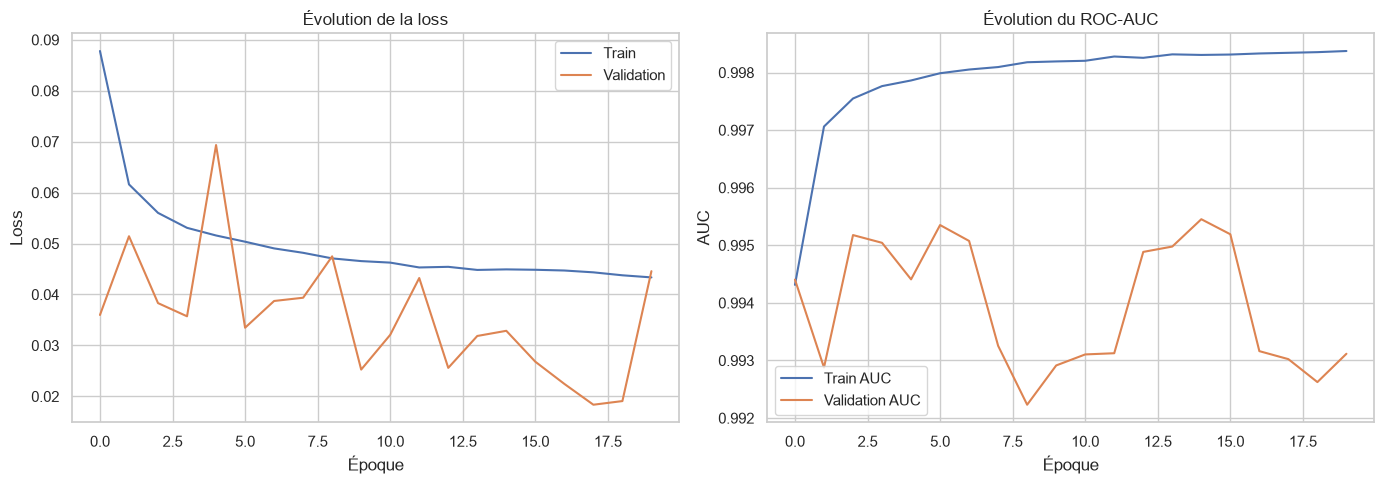

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historique.history['loss'], label='Train')
axes[0].plot(historique.history['val_loss'], label='Validation')
axes[0].set_title('Évolution de la loss')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(historique.history['auc'], label='Train AUC')
axes[1].plot(historique.history['val_auc'], label='Validation AUC')
axes[1].set_title('Évolution du ROC-AUC')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 5. Évaluation et comparaison des modèles

### 5.1 Tableau comparatif des métriques

Les modèles sont classés par **F1-Score** sur la classe fraude. Les colonnes en vert indiquent la meilleure valeur par métrique.

In [24]:
df_resultats = pd.DataFrame(resultats).set_index('Modèle')
df_resultats = df_resultats.sort_values('F1-Score', ascending=False)

print('Comparaison des modèles (triés par F1-Score) :')
print(df_resultats.to_string())

df_resultats.style.highlight_max(color='lightgreen').highlight_min(color='#ffcccc')

Comparaison des modèles (triés par F1-Score) :
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modèle                                                               
Random Forest            0.9996     0.7377  0.9868    0.8443   0.9969
LightGBM                 0.9995     0.6767  0.9825    0.8014   0.9963
XGBoost                  0.9990     0.5210  0.9781    0.6799   0.9959
Réseau de Neurones       0.9885     0.0848  0.9737    0.1560   0.9962
Régression Logistique    0.9638     0.0251  0.8553    0.0488   0.9645


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Random Forest,0.999600,0.737700,0.986800,0.844300,0.996900
LightGBM,0.999500,0.676700,0.982500,0.801400,0.996300
XGBoost,0.999000,0.521000,0.978100,0.679900,0.995900
Réseau de Neurones,0.988500,0.084800,0.973700,0.156000,0.996200
Régression Logistique,0.963800,0.025100,0.855300,0.048800,0.964500


### 5.2 Courbes ROC

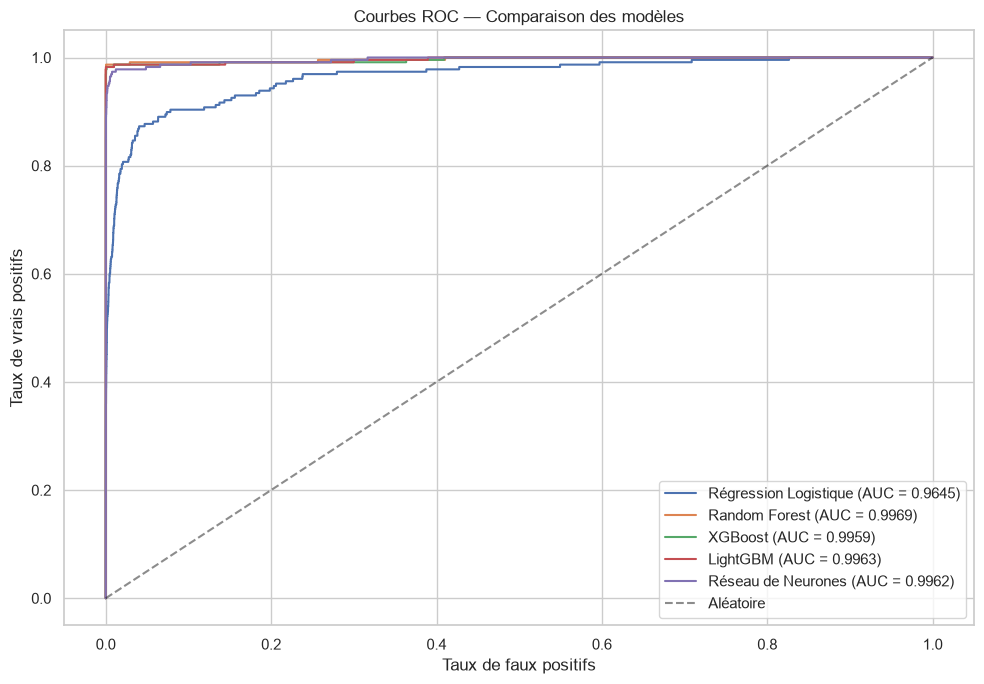

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))

modeles_proba = [
    ('Régression Logistique', y_proba_lr),
    ('Random Forest', y_proba_rf),
    ('XGBoost', y_proba_xgb),
    ('LightGBM', y_proba_lgb),
    ('Réseau de Neurones', y_proba_nn)
]

for nom, proba in modeles_proba:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{nom} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aléatoire')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbes ROC — Comparaison des modèles')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Observation** : La courbe ROC mesure la capacité discriminante de chaque modèle indépendamment du seuil de classification. Un AUC proche de 1 indique un modèle quasi-parfait. Le modèle retenu sera celui combinant le meilleur AUC et le meilleur F1-Score.

### 5.3 Matrice de confusion — Meilleur modèle

La matrice de confusion décompose les erreurs de prédiction en quatre catégories : vrais positifs, vrais négatifs, faux positifs et faux négatifs.

Meilleur modèle : Random Forest
Modèle sauvegardé : ../donnees/traitees/meilleur_modele_fraude.pkl


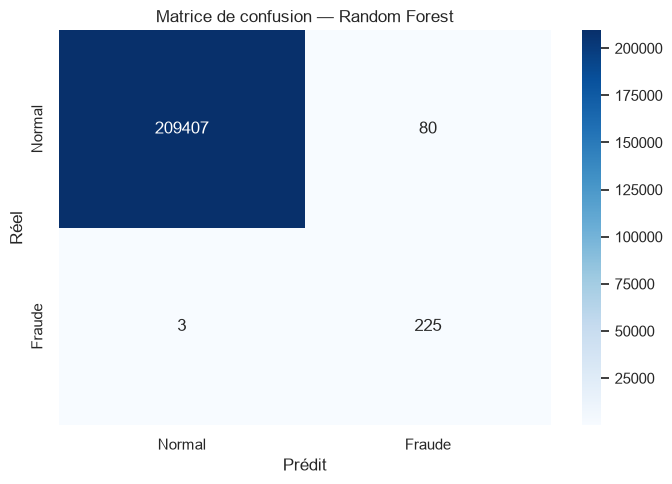

In [26]:
meilleur_nom = df_resultats.index[0]
print(f'Meilleur modèle : {meilleur_nom}')

modeles_pred = {
    'Régression Logistique': (y_pred_lr, lr),
    'Random Forest': (y_pred_rf, rf),
    'XGBoost': (y_pred_xgb, xgb_model),
    'LightGBM': (y_pred_lgb, lgb_model),
    'Réseau de Neurones': (y_pred_nn, nn)
}

y_pred_best, meilleur_modele = modeles_pred[meilleur_nom]

# Sauvegarde du meilleur modèle sur disque pour l'API
sauvegarder_modele(meilleur_modele, '../donnees/traitees/meilleur_modele_fraude.pkl')

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.title(f'Matrice de confusion — {meilleur_nom}')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

---

## 6. Interprétabilité

L'interprétabilité est essentielle dans le domaine financier pour justifier les décisions de blocage auprès des équipes métier et réglementaires. Deux niveaux d'analyse sont conduits :

- **Globale** : quelles variables influencent le plus les prédictions en général
- **Locale** : pourquoi le modèle a-t-il prédit fraude sur telle transaction spécifique

### 6.1 Importance des variables (XGBoost)

XGBoost calcule l'importance de chaque variable selon sa contribution à la réduction de l'impureté sur l'ensemble des arbres de décision.

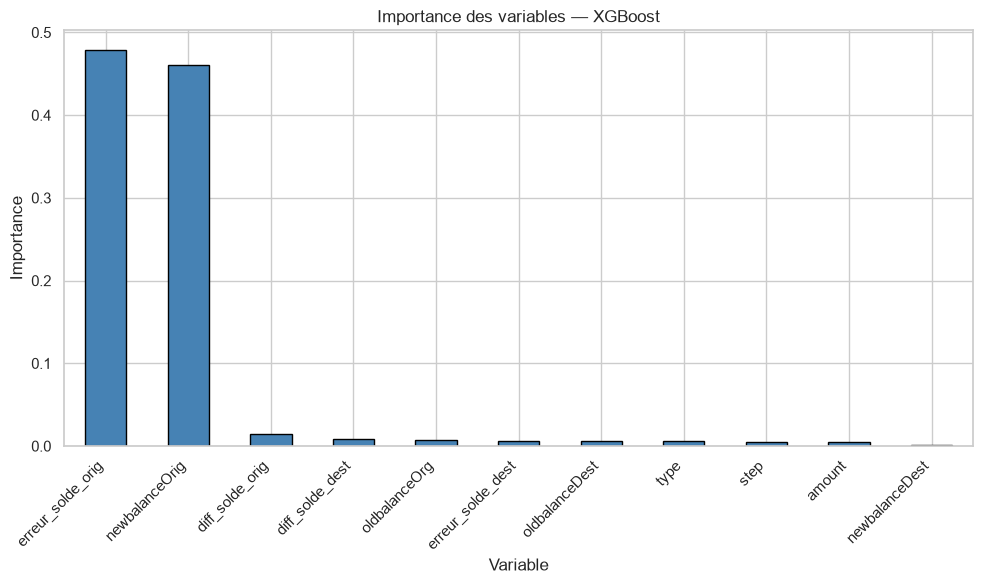

In [27]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Importance des variables — XGBoost')
plt.xlabel('Variable')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.2 Analyse SHAP (SHapley Additive exPlanations)

SHAP est basé sur la théorie des jeux coopératifs. Il mesure la contribution marginale de chaque variable à chaque prédiction individuelle, garantissant une explication cohérente et fidèle au modèle.

- **Graphique bar** : importance globale (valeur absolue moyenne des SHAP)
- **Graphique beeswarm** : impact directionnel — rouge = valeur élevée de la variable, bleu = valeur faible

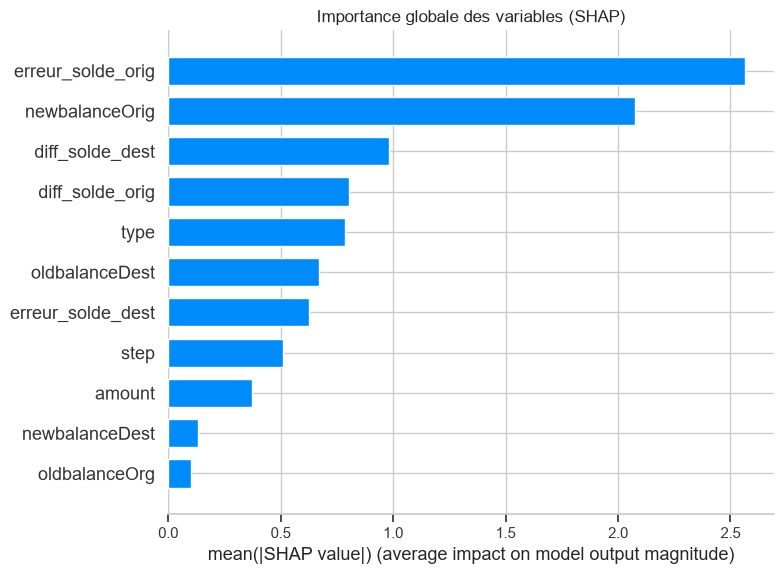

In [28]:
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df.iloc[:500])

shap.summary_plot(shap_values, X_test_df.iloc[:500], plot_type='bar', show=False, max_display=15)
plt.title('Importance globale des variables (SHAP)')
plt.tight_layout()
plt.show()

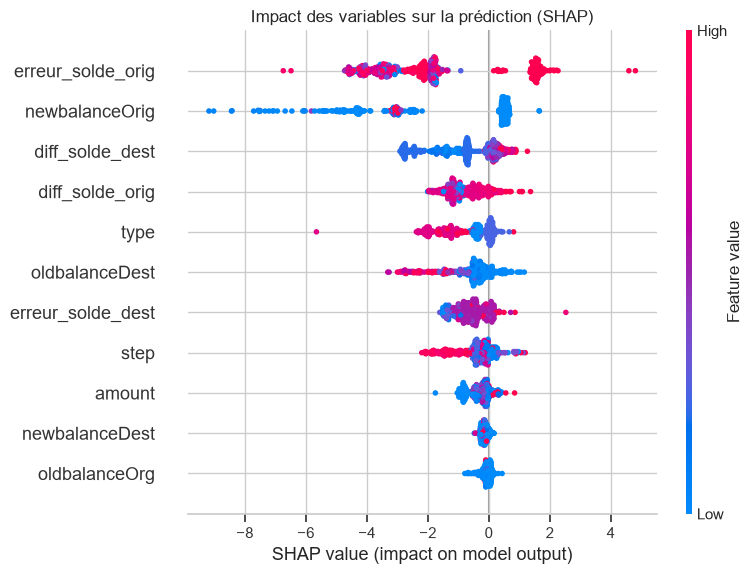

In [29]:
shap.summary_plot(shap_values, X_test_df.iloc[:500], show=False, max_display=15)
plt.title('Impact des variables sur la prédiction (SHAP)')
plt.tight_layout()
plt.show()

**Observation** : Les variables de feature engineering (`erreur_solde_orig`, `diff_solde_orig`) apparaissent systématiquement parmi les plus importantes, confirmant la pertinence de l'étape de construction des variables dérivées. Le type de transaction (`type`) et le montant (`amount`) complètent le profil discriminant.

### 6.3 Analyse des erreurs de classification

Deux types d'erreurs ont des impacts métier distincts :

| Type d'erreur | Définition | Impact |
|---|---|---|
| **Faux positif** | Transaction normale classée fraude | Blocage injustifié → friction client |
| **Faux négatif** | Fraude non détectée | Perte financière directe |

Dans le contexte bancaire, le **faux négatif est l'erreur la plus coûteuse**. L'analyse ci-dessous identifie le profil moyen des fraudes manquées.

In [30]:
X_test_analyse = X_test.copy()
X_test_analyse['y_reel'] = y_test.values
X_test_analyse['y_predit'] = y_pred_best

faux_positifs = X_test_analyse[(X_test_analyse['y_reel'] == 0) & (X_test_analyse['y_predit'] == 1)]
faux_negatifs = X_test_analyse[(X_test_analyse['y_reel'] == 1) & (X_test_analyse['y_predit'] == 0)]

print(f'Faux positifs (normales → fraude)     : {len(faux_positifs):,}')
print(f'Faux négatifs (fraudes non détectées) : {len(faux_negatifs):,}')

print('\nCaractéristiques moyennes des faux négatifs (fraudes ratées) :')
print(faux_negatifs.drop(columns=['y_reel', 'y_predit']).mean())

Faux positifs (normales → fraude)     : 80
Faux négatifs (fraudes non détectées) : 3

Caractéristiques moyennes des faux négatifs (fraudes ratées) :
step                 2.533333e+01
type                 2.000000e+00
amount               5.832718e+05
oldbalanceOrg        2.531882e+04
newbalanceOrig       0.000000e+00
oldbalanceDest       3.165959e+06
newbalanceDest       3.749231e+06
diff_solde_orig      2.531882e+04
diff_solde_dest      5.832718e+05
erreur_solde_orig   -5.579530e+05
erreur_solde_dest    6.666667e-03
dtype: float64


---

## 7. Conclusion et recommandations

### 7.1 Bilan technique

| Étape | Choix technique | Justification |
|---|---|---|
| Déséquilibre | SMOTE sur train uniquement | Préserve la distribution réelle du test |
| Feature engineering | 4 variables de soldes dérivées | Capturent les incohérences comptables des fraudes |
| Encodage | LabelEncoder sur `type` | Variable ordinale à faible cardinalité |
| Métrique principale | F1-Score + Recall (classe fraude) | L'accuracy est trompeuse sur données déséquilibrées |
| Tracking | MLflow | Reproductibilité et comparaison des expériences |

### 7.2 Recommandations opérationnelles

1. **Déploiement** : le modèle retenu sera exposé via une API FastAPI pour intégration dans le système transactionnel existant.

2. **Seuil de décision** : le seuil de 0,5 peut être ajusté selon la tolérance au risque. Abaisser le seuil augmente le Recall (moins de fraudes manquées) au détriment de la Precision (plus de faux positifs).

3. **Monitoring** : surveiller la dérive du taux de fraude détecté en production. Un changement de distribution des transactions (nouveau type de fraude, saisonnalité) peut dégrader les performances.

4. **Réentraînement** : planifier un réentraînement trimestriel avec les nouvelles transactions labelisées par les équipes fraude.

5. **Priorité de surveillance** : concentrer les efforts humains de vérification sur les transactions CASH_OUT et TRANSFER de montants supérieurs au percentile 75.